# Константы, импорты

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve, confusion_matrix
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

TARGET = "stroke"

DATASET_PATH = "./healthcare-dataset-stroke-data.xls"

numeric_cols = ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
numeric_cols_without_id = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Загрузка данных

In [ ]:
df = pd.read_csv(DATASET_PATH)
print('Размер:', df.shape)
print(df[TARGET].value_counts())
df.head()

# Анализ сырых данных

Анализ данных до преобразования категориальных признаков

## Базовый анализ, взгляд на данные

In [ ]:
print('=== Типы данных, количество пропусков ===')
df.info()

In [ ]:
print('=== Статистика по числовым и категориальным признакам ===')
df.describe(include='all')

In [ ]:
print ('=== Количество уникальных значений по колонкам (категориальные колонки) ===')
for col in cat_cols:
    print(f'{col}: {df[col].nunique()}')

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x=TARGET)
plt.xlabel('Инсульт')
plt.ylabel('Количество')
plt.title('Количество записей')
plt.show()

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values)
plt.title('Количество пропусков по столбцам')
plt.ylabel('Количество пропусков')
plt.show()

## Анализ числовых признаков

### Анализ распределения (ящики с усами)

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(numeric_cols_without_id):
    axes[0, i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[0, i].set_title(f'Распределение {col}')
    
    # Boxplot по классам stroke
    sns.boxplot(data=df, x=TARGET, y=col, ax=axes[1, i])
    axes[1, i].set_title(f'{col} по {TARGET}')

### Анализ распределения (Skewness)

In [ ]:
from scipy.stats import skew
print(df[numeric_cols].apply(skew))

### Анализ выбросов

In [ ]:
plt.figure(figsize=(12,4))
num_cols = ['age', 'avg_glucose_level', 'bmi']
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Анализ категориальных признаков

### Столбчатые диаграммы для категориальных признаков

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='stroke')
    plt.title(f'Распределение {col} по stroke')
    plt.xticks(rotation=45)
    plt.show()

# Подготовка данных. Преобразование категориальных признаков

In [ ]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)
df['smoking_status'].fillna(df['smoking_status'].mode()[0], inplace=True)

X = df.drop(TARGET, axis=1)
y = df[TARGET]

label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Анализ данных после преобразования

## HeatMap параметров

In [ ]:
df_encoded = X.copy()
df_encoded[TARGET] = y

corr = df_encoded.corr()

corr_with_target = corr[TARGET].drop(TARGET).sort_values(ascending=False)

print(f"Топ-10 признаков, наиболее коррелирующих с {TARGET}:")
print(corr_with_target.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Корреляция признаков с целевой переменной ' + TARGET)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.ylabel('Признаки')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# Feature Engineering

На предыдущем шаге стали известны параметры, которые более всего влияют на сигнал Stroke. На основе этой информации можно вывести новые признаки

In [ ]:
def create_features(df):
    df_new = df.copy()
    df_new['age_group'] = pd.cut(df_new['age'], bins=[0, 40, 60, 80, 120], labels=[0,1,2,3])
    df_new['bmi_group'] = pd.cut(df_new['bmi'], bins=[0, 18.5, 25, 30, 100], labels=[0,1,2,3])
    df_new['age_hypertension'] = df_new['age'] * df_new['hypertension']
    return df_new

# Разделение данных на тренировочную и тестовую выборки

In [ ]:
X_enhanced = create_features(X)
# Удаляем id, gender, Residence_type т.к. они почти не коррелируют со stroke
X_enhanced = X_enhanced.drop(['id', 'gender', 'Residence_type'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=1610, stratify=y
)

# Обучение модели

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

scoring = {
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

base_model = RandomForestClassifier(random_state=1610)

grid = GridSearchCV(base_model, 
                    param_grid, 
                    cv=5, 
                    scoring=scoring,
                    refit='f1', 
                    n_jobs=-1, 
                    verbose=1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Лучшие параметры:", grid.best_params_)

model = best_model

y_pred = model.predict_proba(X_test)[:, 1]

# Понижаем порог проверки для уменьшения false/positive 

In [106]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)

# Находим индекс порога с максимальным F1
best_idx = np.argmax(f1_scores)
threshold = thresholds[best_idx]

print(f"Оптимальный порог (по max F1): {threshold:.3f}")

# Применяем порог
y_pred_custom = (y_pred >= threshold).astype(int)

Оптимальный порог (по max F1): 0.519


# Оценка качества

In [107]:
def print_metrics_explained(y_true, y_pred, target_names):
    """
    Печатает краткое объяснение метрик классификации.
    """

    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    acc = report['accuracy']
    
    print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}% правильных ответов)")
    
    for name in target_names:
        m = report[name]
        print(f"\nКласс '{name}':")
        print(f"  precision = {m['precision']:.2f}  ({m['precision']*100:.0f}% предсказанных верны)")
        print(f"  recall    = {m['recall']:.2f}    ({m['recall']*100:.0f}% реальных найдены)")
        print(f"  f1-score  = {m['f1-score']:.2f}")
    
    macro = report['macro avg']
    weighted = report['weighted avg']
    print("\nСредние:")
    print(f"  macro avg    precision={macro['precision']:.2f}, recall={macro['recall']:.2f}, f1={macro['f1-score']:.2f}")
    print(f"  weighted avg precision={weighted['precision']:.2f}, recall={weighted['recall']:.2f}, f1={weighted['f1-score']:.2f}")

In [108]:
print_metrics_explained(y_test, y_pred_custom, ['Нет инсульта', 'Инсульт'])

Accuracy: 0.8767  (87.67% правильных ответов)

Класс 'Нет инсульта':
  precision = 0.97  (97% предсказанных верны)
  recall    = 0.89    (89% реальных найдены)
  f1-score  = 0.93

Класс 'Инсульт':
  precision = 0.21  (21% предсказанных верны)
  recall    = 0.54    (54% реальных найдены)
  f1-score  = 0.30

Средние:
  macro avg    precision=0.59, recall=0.72, f1=0.62
  weighted avg precision=0.94, recall=0.88, f1=0.90


# График "Предсказание VS Реальность"

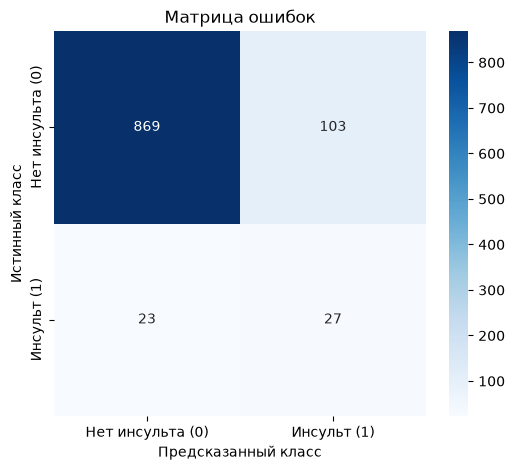

In [109]:
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Нет инсульта (0)', 'Инсульт (1)'],
            yticklabels=['Нет инсульта (0)', 'Инсульт (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()